## Objective:
The objective of this assignment is to implement and evaluate the K-Nearest Neighbours algorithm for classification using the given datasets
Dataset:
Need to Classify the animal type
## Tasks:
1. Analyse the data using the visualizations
2. Preprocess the data by handling missing values & Outliers, if any.
3. Split the dataset into training and testing sets (80% training, 20% testing).
4. Implement the K-Nearest Neighbours algorithm using a machine learning library like scikit-learn On training dataset
5. Choose an appropriate distance metric and value for K.
6. Evaluate the classifier's performance on the testing set using accuracy, precision, recall, and F1-score metrics.
7. Visualize the decision boundaries of the classifier.


In [1]:
# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Zoo.csv to Zoo.csv


In [4]:
# Step 2: Load the dataset
df = pd.read_csv("Zoo.csv")

In [5]:
# Step 3: Display basic info
print("Dataset Shape:", df.shape)
print("\nDataset Columns:\n", df.columns)
print("\nFirst 5 Rows:\n", df.head())

Dataset Shape: (101, 18)

Dataset Columns:
 Index(['animal name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'type'],
      dtype='object')

First 5 Rows:
   animal name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1

In [6]:
# Step 4: Check for missing values
print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64


In [7]:
# Step 5: Statistical summary
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
              hair    feathers        eggs        milk    airborne     aquatic  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.425743    0.198020    0.584158    0.405941    0.237624    0.356436   
std      0.496921    0.400495    0.495325    0.493522    0.427750    0.481335   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    1.000000    0.000000    0.000000    0.000000   
75%      1.000000    0.000000    1.000000    1.000000    0.000000    1.000000   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

         predator     toothed    backbone    breathes    venomous        fins  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.554455    0.603960    0.821782    0.792079    0.079208    0.168317   
std 

In [9]:
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Set style for better visuals
sns.set(style="whitegrid", palette="Set2")

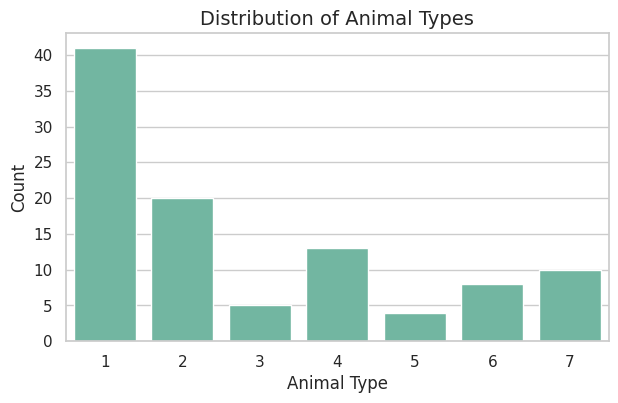

In [11]:
# 1️ Class Distribution
plt.figure(figsize=(7,4))
sns.countplot(x='type', data=df)
plt.title("Distribution of Animal Types", fontsize=14)
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.show()

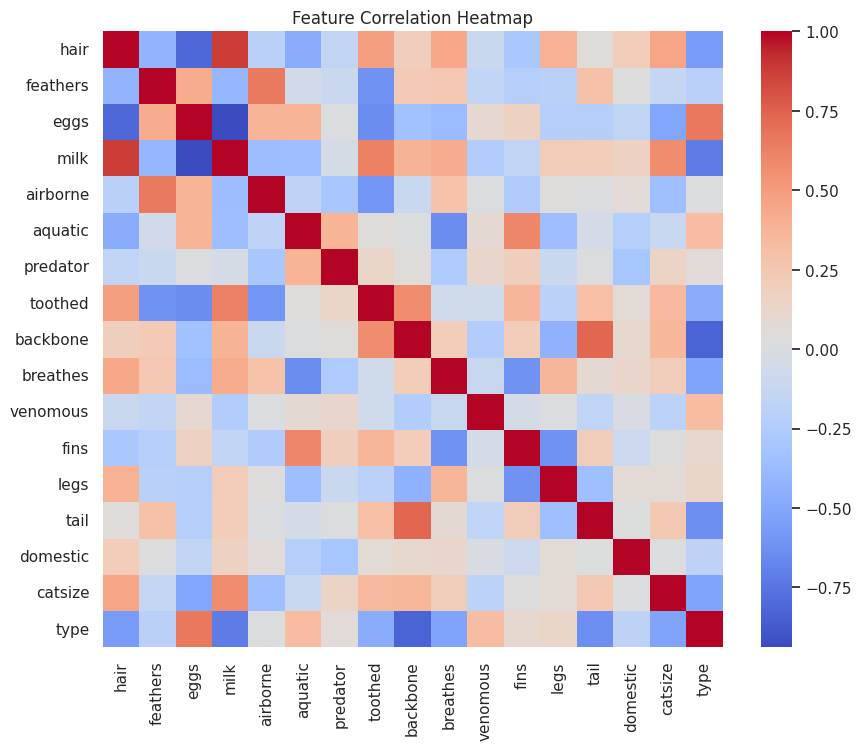

In [12]:
# 2️ Pairwise correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('animal name', axis=1).corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


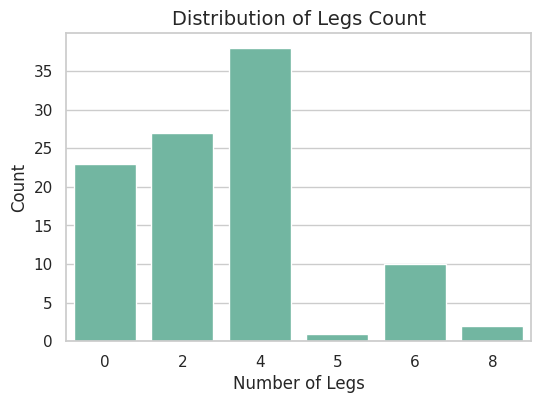

In [13]:
# 3️ Legs count distribution
plt.figure(figsize=(6,4))
sns.countplot(x='legs', data=df)
plt.title("Distribution of Legs Count", fontsize=14)
plt.xlabel("Number of Legs")
plt.ylabel("Count")
plt.show()


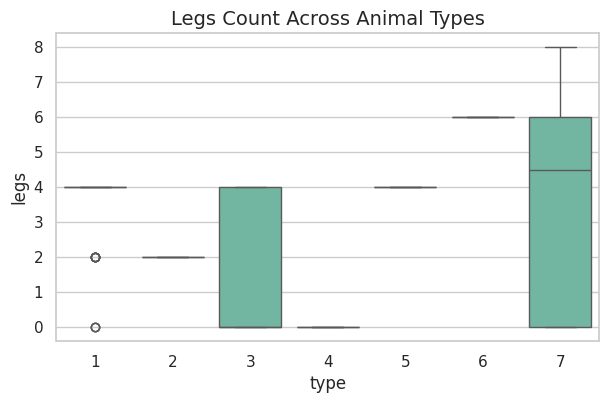

In [14]:
# 4️ Relationship between Legs and Animal Type
plt.figure(figsize=(7,4))
sns.boxplot(x='type', y='legs', data=df)
plt.title("Legs Count Across Animal Types", fontsize=14)
plt.show()

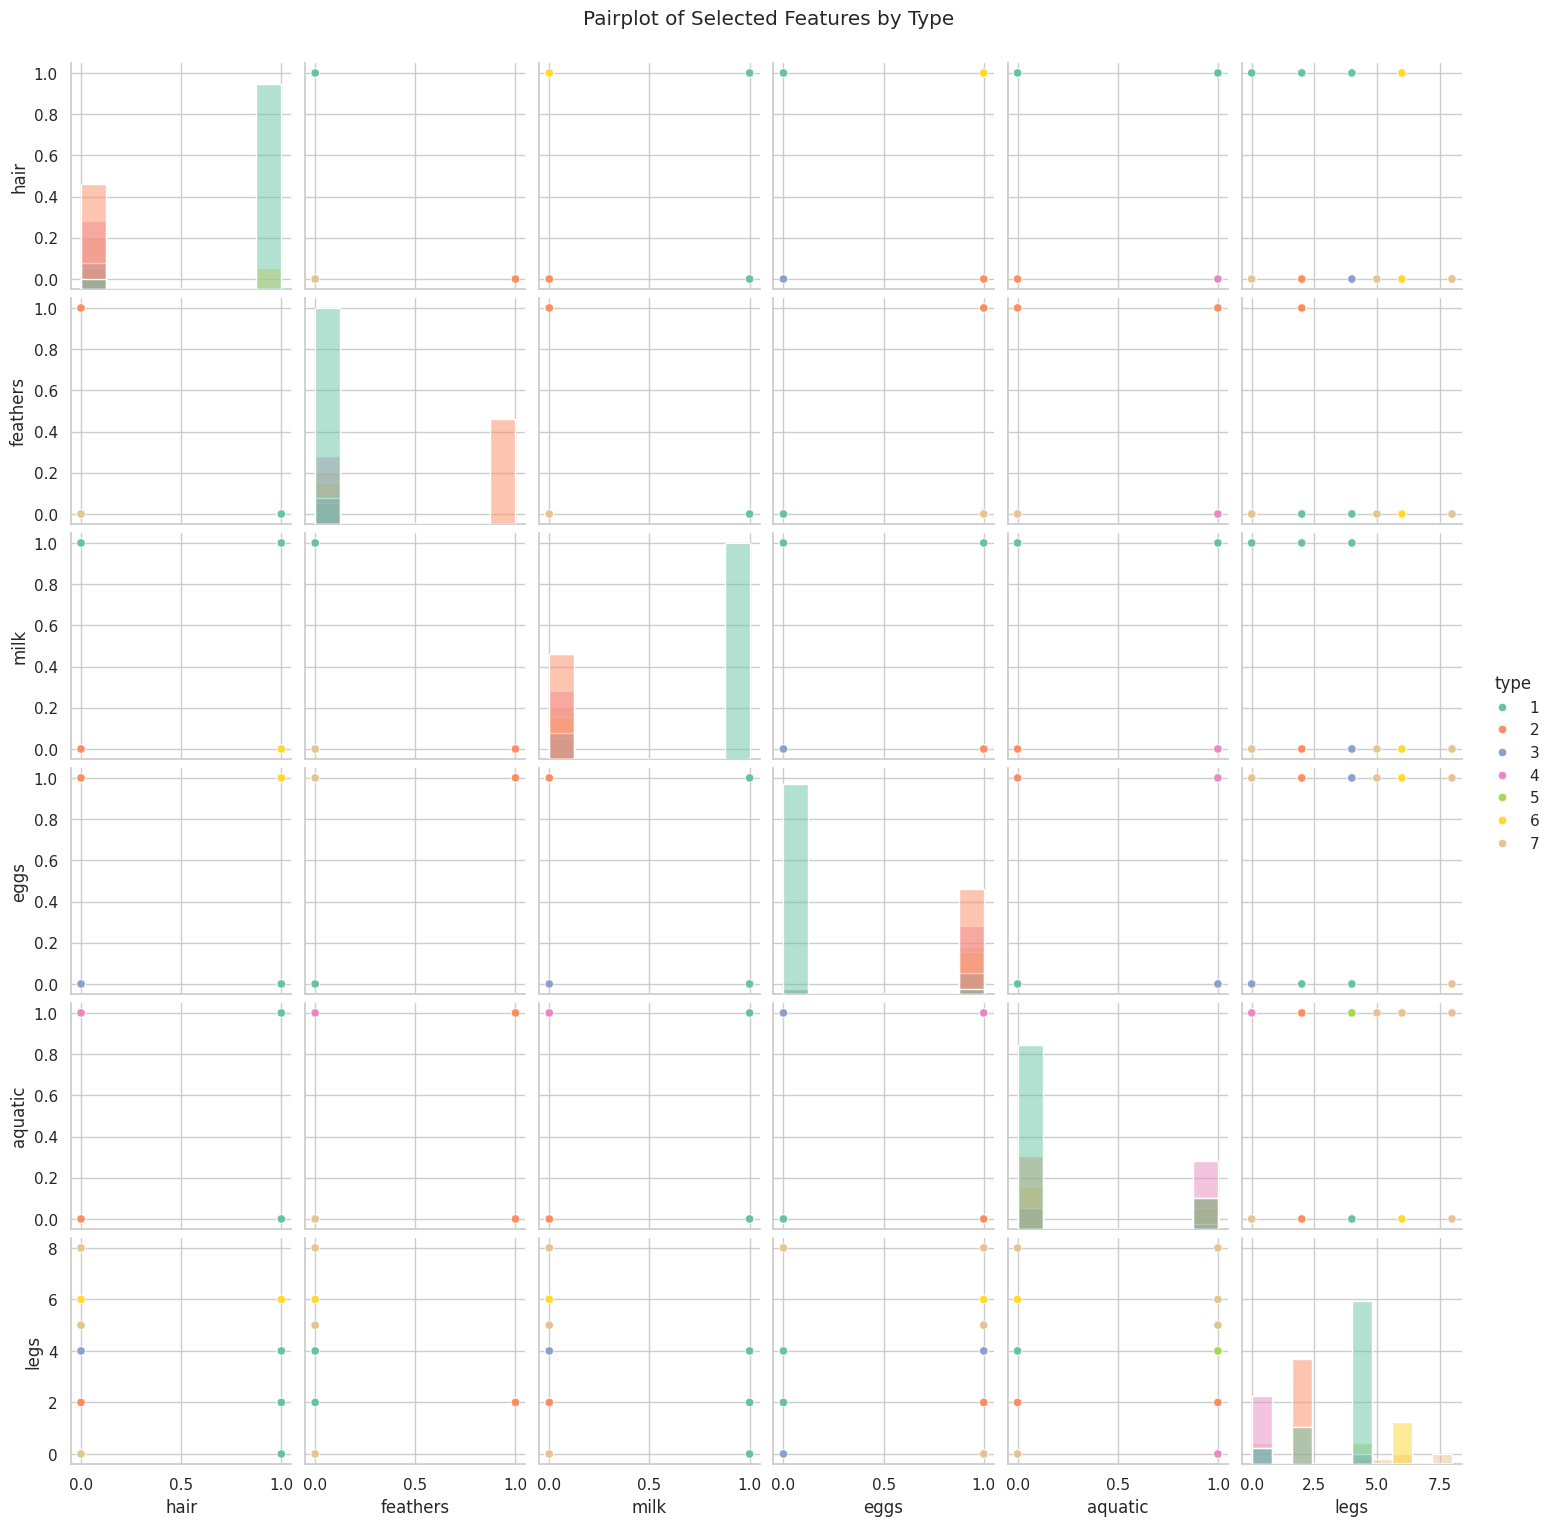

In [15]:
# 5️ Pairplot for selected important features
selected_features = ['hair', 'feathers', 'milk', 'eggs', 'aquatic', 'legs', 'type']
sns.pairplot(df[selected_features], hue='type', palette='Set2', diag_kind='hist')
plt.suptitle("Pairplot of Selected Features by Type", y=1.02)
plt.show()

In [16]:
# 2. Preprocess the data by handling missing values & Outliers, if any.

# 1️ Check missing values
print("Missing Values in Each Column:\n", df.isnull().sum())

Missing Values in Each Column:
 animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64


 No missing values found in the dataset

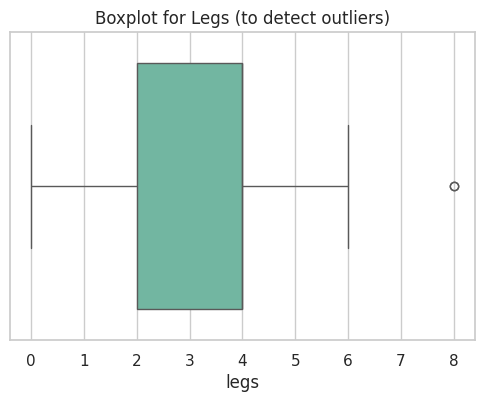

In [17]:
#  Check for outliers (only for 'legs' column, since others are binary)
plt.figure(figsize=(6,4))
sns.boxplot(x=df['legs'])
plt.title("Boxplot for Legs (to detect outliers)")
plt.show()

In [18]:
#  Display unique leg values
print("\nUnique leg values:", df['legs'].unique())


Unique leg values: [4 0 2 6 8 5]


In [19]:
# If any extreme value (like >8) found, we can replace or remove it
if df['legs'].max() > 8:
    print("\n Outliers detected in legs column — cleaning them...")
    df = df[df['legs'] <= 8]
else:
    print("\n No outliers detected in legs column.")


 No outliers detected in legs column.


In [20]:
# 3. Split the dataset into training and testing sets (80% training, 20% testing).

from sklearn.model_selection import train_test_split

# Drop 'animal name' because it's not a feature
X = df.drop(['animal name', 'type'], axis=1)
y = df['type']

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Display dataset shapes
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)
print("\n Dataset successfully split into training and testing sets.")

Training Set Shape: (80, 16)
Testing Set Shape: (21, 16)

 Dataset successfully split into training and testing sets.


In [22]:
import warnings
warnings.filterwarnings('ignore')

In [23]:
# 4. Implement K-Nearest Neighbours (KNN) Classifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create KNN model with k=5 (you can tune later)
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# Train the model on the training data
knn.fit(X_train, y_train)

# Predict on the testing set
y_pred = knn.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9524

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       0.00      0.00      0.00         1
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           0.95        21
   macro avg       0.82      0.86      0.84        21
weighted avg       0.92      0.95      0.93        21


Confusion Matrix:
 [[8 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 3 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 2 0]
 [0 0 0 0 0 0 2]]


In [24]:
# 5. Choosing the best value of K and distance metric

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define parameter grid
param_grid = {
    'n_neighbors': list(range(1, 21)),  # K from 1 to 20
    'metric': ['euclidean', 'manhattan', 'minkowski']
}


In [25]:
# Initialize KNN
knn = KNeighborsClassifier()

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Display best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 1}
Best Cross-Validation Accuracy: 0.95


In [31]:
# 6. Evaluate the classifier's performance on the testing set

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
# Initialize KNN model with chosen parameters (k=1, metric='euclidean')
knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')

# Train the model
knn.fit(X_train, y_train)

# Predictions on test data
y_pred = knn.predict(X_test)

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Print results
print("KNN Model Evaluation Metrics:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


KNN Model Evaluation Metrics:
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Detailed Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



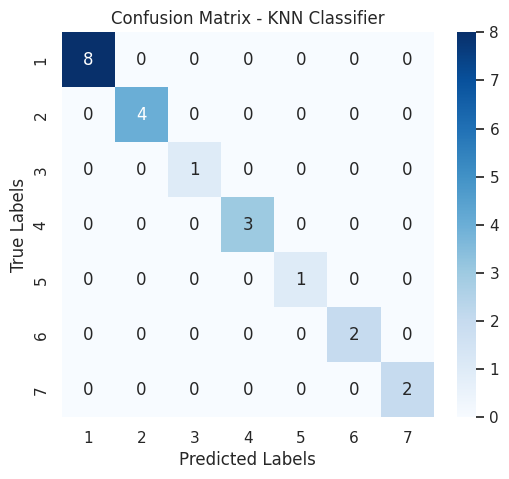

In [34]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.title('Confusion Matrix - KNN Classifier')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [35]:
# 7. Visualize Decision Boundaries (using PCA for 2D projection)

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

In [36]:
# Reduce dataset to 2 principal components for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


In [37]:
# Retrain KNN on reduced 2D data
knn_pca = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn_pca.fit(X_train_pca, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=1)

In [38]:
# Create a mesh grid for plotting decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

In [39]:
# Predict across grid
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

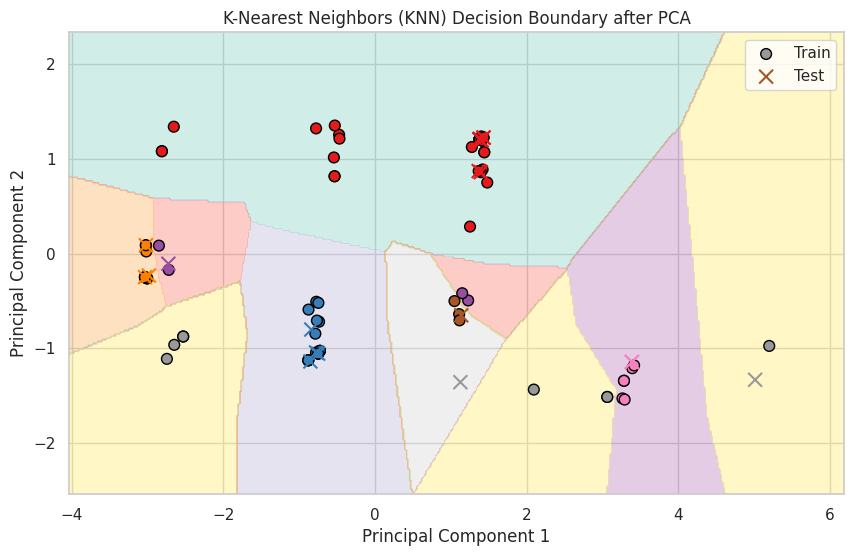

In [40]:
# Plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='Set3')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, label="Train", edgecolor='k', cmap='Set1', s=60)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, label="Test", marker='x', cmap='Set1', s=100)
plt.title("K-Nearest Neighbors (KNN) Decision Boundary after PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

#

## Interview Questions:
### 1. What are the key hyperparameters in KNN?
In K-Nearest Neighbours, the main things we have to choose are:

K value (number of neighbours): It means how many nearby data points are used to make a decision.

Distance metric: It defines how distance between two points is measured.

Weights: It decides whether all neighbours have equal importance or closer ones have more effect.

Algorithm: It specifies the method used to find the nearest neighbours

---

### 2. What distance metrics can be used in KNN?
There are different distance measures that can be used in KNN:

Euclidean distance: The straight-line distance between two points (most commonly used).

Manhattan distance: Distance measured along grid lines (like moving up, down, left, right).

Minkowski distance: A general form that can act like Euclidean or Manhattan based on its parameter.

Hamming distance: Used when features are categorical or binary.